<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/Loan_Delinquent_Analysis_Case_Study_(Decision_Tree).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Delinquent Analysis Case Study**

# **Business Context**


DRS bank is facing challenging times. Their NPAs (Non-Performing Assets) have been on a rise recently and a large part of these are due to the loans given to individual customers(borrowers). The Chief Risk Officer of the bank decides to put in a scientifically robust framework for approval of loans to individual customers to minimize the risk of loans converting into NPAs and initiates a project for the data science team at the bank. You, as a senior member of the team, are assigned this project.

# **Objective**

**To identify the criteria to approve loans for an individual customer such that the likelihood of the loan delinquency is minimized and identify the factors that drive the behavior of loan delinquency.**

# **Dataset**

**ID:** Customer ID

**isDelinquent :** indicates whether the customer is delinquent or not (1 => Yes, 0 => No)

**term:** Loan term in months

**gender:** Gender of the borrower

**age:** Age of the borrower

**purpose:** Purpose of Loan

**home_ownership:** Status of borrower's home

**FICO:** FICO (i.e. the bureau score) of the borrower

# **Domain Information**

**Transactor –** A person who pays his due amount balance full and on time.

**Revolver –** A person who pays the minimum due amount but keeps revolving his
balance and does not pay the full amount.

**Delinquent -** Delinquency means that you are behind on payments, a person who fails to pay even the minimum due amount.

**Defaulter –** Once you are delinquent for a certain period your lender will declare you to be in the default stage.

**Risk Analytics –** A wide domain in the financial and banking industry, basically analyzing the risk of the customer.


In [209]:
# Importing all the libraries
# to load data
import pandas as pd
import numpy as np
import math
# to visualize data
import seaborn as sns
import matplotlib.pyplot as plt

# to maintain the number precision
pd.options.display.float_format = '{:.5f}'.format

# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# to split data into training & testing
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


# to tune different models
from sklearn.model_selection import GridSearchCV

# to perform statistical analysis
import scipy.stats as stats

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report
)


In [210]:
# connecting google drive to colab
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [211]:
# Load data
try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/Loan_Delinquent_Dataset.csv')
  print(" 🚀 Data loaded successfuly")
except Exception as a :
  print(a)

 🚀 Data loaded successfuly


In [212]:
# Copy original data
df = data.copy()

In [213]:
#Checking data Shape
rows, column = df.shape
print(f"Total Rows = {rows} \nTotal Columns = {column}")

Total Rows = 11548 
Total Columns = 8


In [214]:
# data overview
df.head()

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
0,1,1,36 months,Female,House,Mortgage,>25,300-500
1,2,0,36 months,Female,House,Rent,20-25,>500
2,3,1,36 months,Female,House,Rent,>25,300-500
3,4,1,36 months,Female,Car,Mortgage,>25,300-500
4,5,1,36 months,Female,House,Rent,>25,300-500


In [215]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              11548 non-null  int64 
 1   isDelinquent    11548 non-null  int64 
 2   term            11548 non-null  object
 3   gender          11548 non-null  object
 4   purpose         11548 non-null  object
 5   home_ownership  11548 non-null  object
 6   age             11548 non-null  object
 7   FICO            11548 non-null  object
dtypes: int64(2), object(6)
memory usage: 721.9+ KB


Total 8 columns, 11548 rows. 2 column were numerical & 6 columns were categorical.

No Null values are present

In [216]:
# checking duplicasy
df.duplicated().sum()

np.int64(0)

No duplicasy is present in dataset

In [217]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,11548.00000,5774.50000,3333.76479,1.00000,2887.75000,5774.50000,8661.25000,11548.00000
isDelinquent,11548.00000,0.66860,0.47074,0.00000,0.00000,1.00000,1.00000,1.00000


In [218]:
df.describe(include= ['object', 'category']).T

,count,unique,top,freq
term,11548,2,36 months,10589
gender,11548,2,Male,6555
purpose,11548,7,House,6892
home_ownership,11548,3,Mortgage,5461
age,11548,2,20-25,5888
FICO,11548,2,300-500,6370


-11548 total rows in data.  
- 36 month tenuer time for a loan is on higher side

In [219]:
attributes = df.iloc[:,1:].columns.tolist()

for i in attributes :
  a = df[i].value_counts()
  print(a)
  print("-----------------------------------")

isDelinquent
1    7721
0    3827
Name: count, dtype: int64
-----------------------------------
term
36 months    10589
60 months      959
Name: count, dtype: int64
-----------------------------------
gender
Male      6555
Female    4993
Name: count, dtype: int64
-----------------------------------
purpose
House       6892
Car         2080
Other        928
Personal     892
Wedding      408
Medical      266
other         82
Name: count, dtype: int64
-----------------------------------
home_ownership
Mortgage    5461
Rent        5216
Own          871
Name: count, dtype: int64
-----------------------------------
age
20-25    5888
>25      5660
Name: count, dtype: int64
-----------------------------------
FICO
300-500    6370
>500       5178
Name: count, dtype: int64
-----------------------------------


In the **'purpose'** column, the value **['Other', 'other']** appears in multiple inconsistent formats. We will standardize it to a single format to ensure easier and more accurate analysis.

In [220]:
df['purpose'] = df['purpose'].str.capitalize()

In [221]:
# here ID column is unique sequence column not needed longer to annalysis so, planed to srop this column
df.drop('ID', axis=1, inplace = True)

## **EDA**

###**Univariate Analysis**

In [222]:
def histplot_boxplot(df, features:list):

  """
  Plot Histogram and Boxplot for given features.

    Parameters:
    ----------
    df : pandas.DataFrame
        Input dataset
    features : list
        List of numerical column names

    Returns:
    -------
    None
  """
  n_column = 3
  n_rows = math.ceil(len(features)/n_column)
  # Defining the plot size of histogram
  plt.figure(figsize = (18, 3*n_rows))
  # plotting the histplot using features & data
  for j, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, j + 1)
    sns.histplot(data = df, x = feature, kde = True, color = 'skyblue')

    plt.title(f"Histogram of {feature}")
  plt.tight_layout
  plt.show()

    # ploting boxplot using features list & data
  plt.figure(figsize = (18, 3* n_rows))
  for k, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, k + 1)
    sns.boxplot(data = df, x = feature, color = 'lightgreen')

    plt.title(f"Boxplot of {feature}")

  plt.tight_layout
  plt.show()

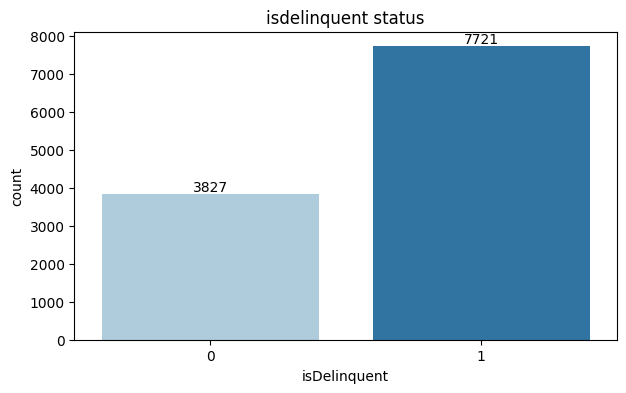

In [223]:
# plotting isdelinquent customer count
plt.figure(figsize= (7,4))
plt.title("isdelinquent status")
plot_1 = sns.countplot(data=df, x = 'isDelinquent',palette="Paired")

# used to print the total count on bar
for value in plot_1.containers :
  plot_1.bar_label(value)

plt.show()

**Around 67% of borrowers are delinquent & 33% of borrowers are non delinquent**

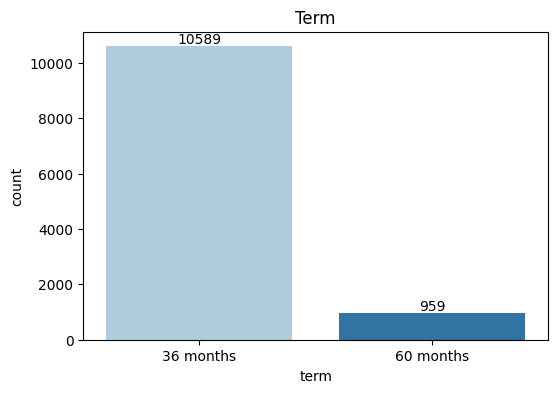

In [224]:
# checking the term
plt.figure(figsize = (6,4))
plt.title("Term")
plot_2 = sns.countplot(data=df, x = 'term', palette="Paired")
for value in plot_2.containers :
  plot_2.bar_label(value)

plt.show()

**Most loans are issued with a tenure of 3 months, which may indicate that the loan amounts are relatively smaller for this duration.**

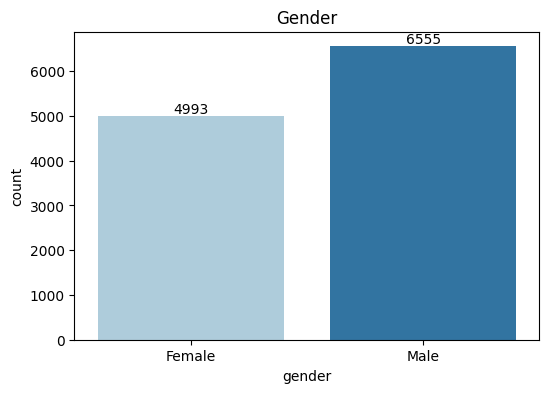

In [225]:
# checking the gender
plt.figure(figsize = (6,4))
plt.title("Gender")
plot_3 = sns.countplot(data=df, x = 'gender', palette="Paired")
for value in plot_3.containers :
  plot_3.bar_label(value)

plt.show()

**The proportion of borrowers is higher among males compared to females.**

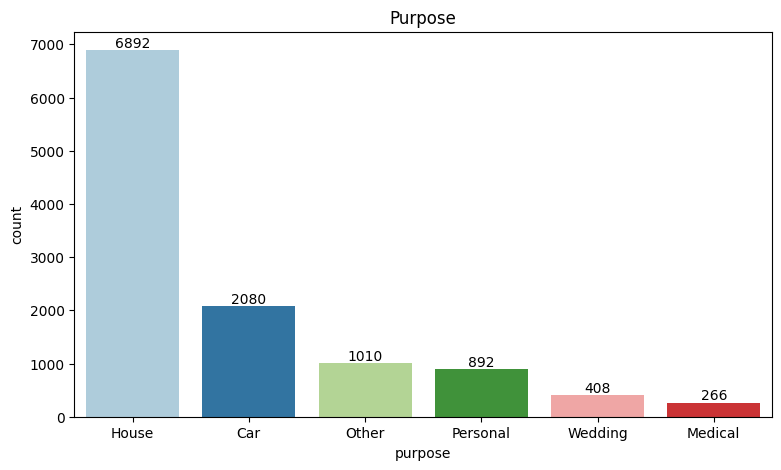

In [226]:
# checking the purpose
plt.figure(figsize = (9,5))
plt.title("Purpose")
plot_3 = sns.countplot(data=df, x = 'purpose', palette="Paired")
for value in plot_3.containers :
  plot_3.bar_label(value)

plt.show()

**A larger proportion of borrowers take loans for 'house' and 'car' purposes.**

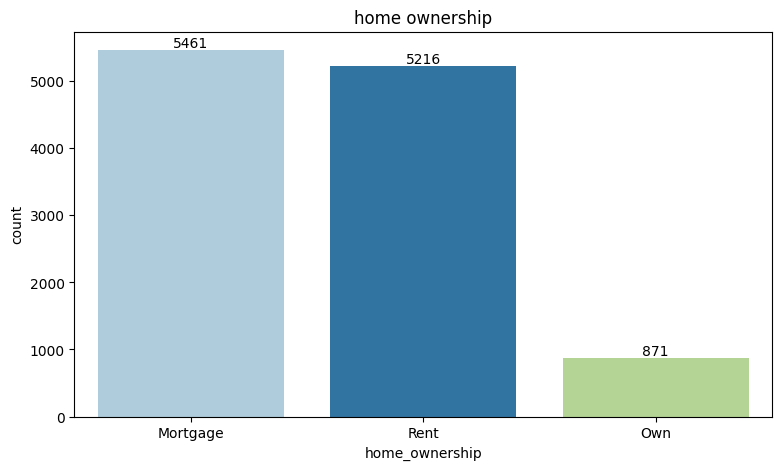

In [227]:
# checking the home ownership
plt.figure(figsize = (9,5))
plt.title("home ownership")
plot_3 = sns.countplot(data=df, x = 'home_ownership',palette="Paired")
for value in plot_3.containers :
  plot_3.bar_label(value)

plt.show()

* A significant proportion of borrowers fall under housing statuses such as Mortgage and Rent. This attribute may have a strong influence on loan repayment behavior, particularly in the delinquent category.

* Only 7.54% of borrowers own their homes.

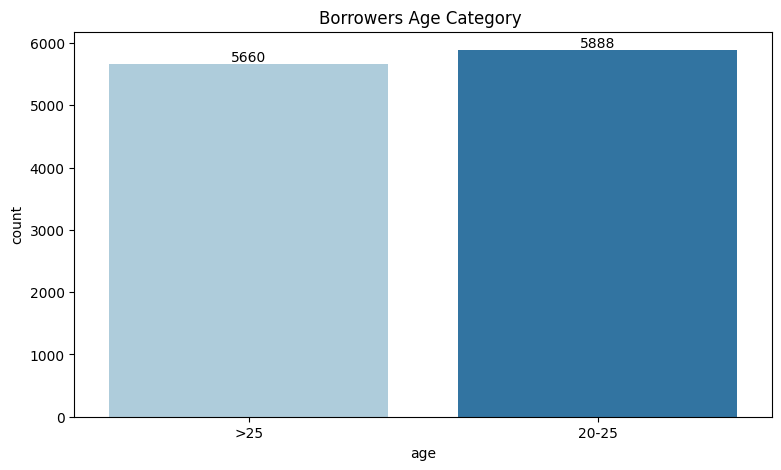

In [228]:
# checking the Age category
plt.figure(figsize = (9,5))
plt.title("Borrowers Age Category ")
plot_3 = sns.countplot(data=df, x = 'age', palette="Paired")
for value in plot_3.containers :
  plot_3.bar_label(value)

plt.show()

51% borrowers age ranges between 20-25 & 49% of borrowers age > 25 years.

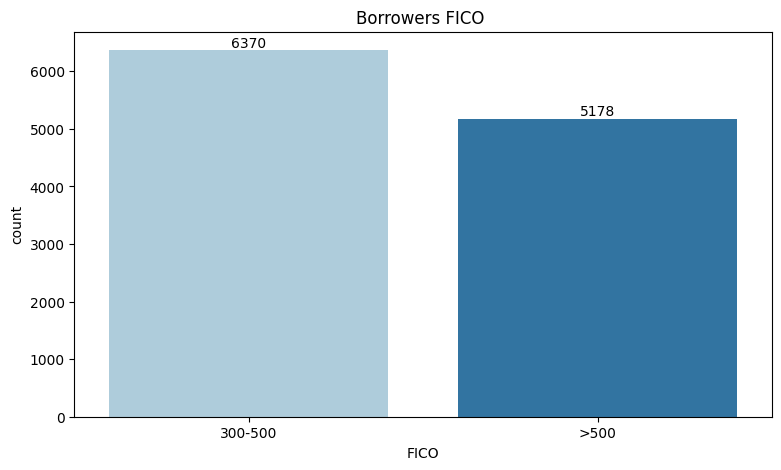

In [229]:
# checking the FICO
plt.figure(figsize = (9,5))
plt.title("Borrowers FICO ")
plot_3 = sns.countplot(data=df, x = 'FICO', palette="Paired")
for value in plot_3.containers :
  plot_3.bar_label(value)

plt.show()

44% of borrowers FICO > 500 & 56% of orrowers FICO is ranges between 300-500

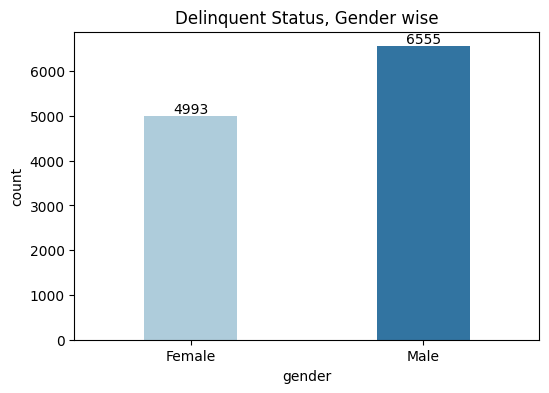

In [230]:
# checking the gender
plt.figure(figsize = (6,4))
plt.title("Delinquent Status, Gender wise")
plot_3 = sns.countplot(data=df, x = 'gender',width=0.4, palette="Paired")
for value in plot_3.containers :
  plot_3.bar_label(value)

plt.show()

### **Bivariate Analysis**

In [231]:
def bargraph_plot(data, x, hue):

    summary = data.groupby([x, hue]).size().div(data.shape[0]).reset_index(name='Percentage')

    n = data[x].nunique()
    plt.figure(figsize=(n*3.5, 4))

    bar_width = min(0.8, max(0.8, 2/n))

    plt.title(f"{x} Vs. {hue}")

    plot = sns.countplot(data=data, x=x, hue=hue, palette="viridis", width=bar_width)

    plt.ylim(0, data[x].value_counts().max())

    # 👉 Add percentage labels
    for container in plot.containers:
        labels = []
        for bar in container:
            height = bar.get_height()

            # Get corresponding percentage
            x_val = bar.get_x() + bar.get_width() / 2
            labels.append(f"{(height/len(data))*100:.1f}%")

        plot.bar_label(container, labels=labels)

    plt.show()

    return summary

In [232]:
df.head()

,isDelinquent,term,gender,purpose,home_ownership,age,FICO
0,1,36 months,Female,House,Mortgage,>25,300-500
1,0,36 months,Female,House,Rent,20-25,>500
2,1,36 months,Female,House,Rent,>25,300-500
3,1,36 months,Female,Car,Mortgage,>25,300-500
4,1,36 months,Female,House,Rent,>25,300-500


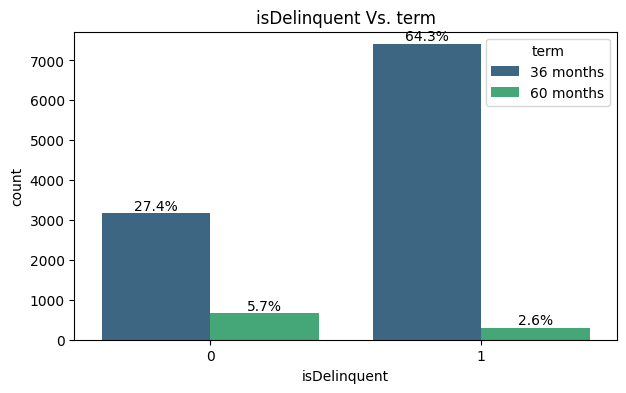

,isDelinquent,term,Percentage
0,0,36 months,0.27433
1,0,60 months,0.05707
2,1,36 months,0.64262
3,1,60 months,0.02598


In [233]:
bargraph_plot(df, 'isDelinquent', 'term')

The 36-month loan tenure is the most preferred option among borrowers, indicating a clear trend toward this duration. Additionally, a higher proportion of delinquent borrowers is observed within the 36-month loan segment.

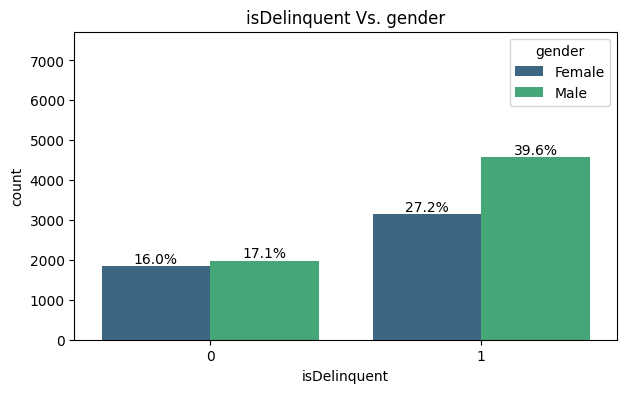

,isDelinquent,gender,Percentage
0,0,Female,0.16020
1,0,Male,0.17120
2,1,Female,0.27217
3,1,Male,0.39643


In [234]:
bargraph_plot(df, 'isDelinquent', 'gender')

Male borrowers show a higher delinquency rate (39.6%) compared to females (27.2%).
This indicates that male customers are more likely to default on loans.

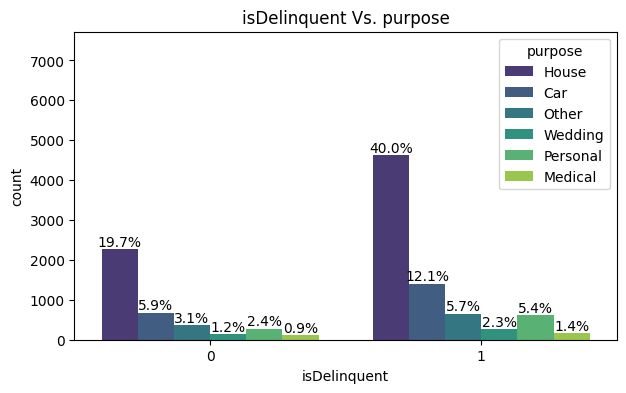

,isDelinquent,purpose,Percentage
0,0,Car,0.05871
1,0,House,0.19674
2,0,Medical,0.00927
3,0,Other,0.03091
4,0,Personal,0.02373
5,0,Wedding,0.01204
6,1,Car,0.12141
7,1,House,0.40007
8,1,Medical,0.01377
9,1,Other,0.05655


In [235]:
bargraph_plot(df, 'isDelinquent', 'purpose')

Borrowers who have taken loans for purposes such as housing, cars, and personal needs show higher delinquency rates, indicating that these segments are relatively riskier.

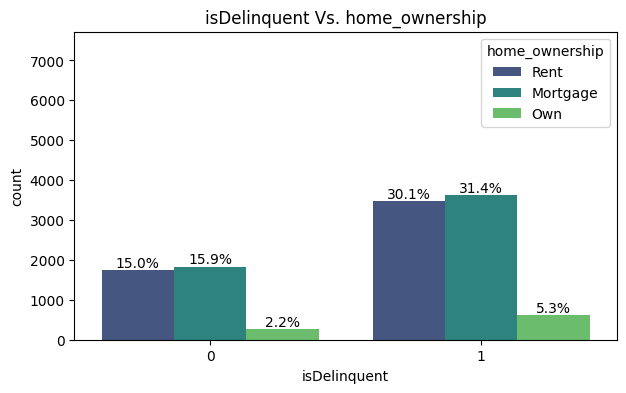

,isDelinquent,home_ownership,Percentage
0,0,Mortgage,0.15856
1,0,Own,0.02243
2,0,Rent,0.15042
3,1,Mortgage,0.31434
4,1,Own,0.05300
5,1,Rent,0.30126


In [236]:
bargraph_plot(df, 'isDelinquent', 'home_ownership')

Customers with housing status as rent or mortgage exhibit higher delinquency rates, indicating that they are relatively riskier borrower segments.

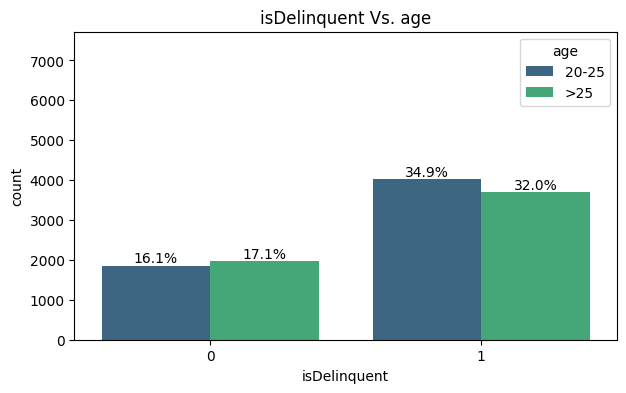

,isDelinquent,age,Percentage
0,0,20-25,0.16089
1,0,>25,0.17051
2,1,20-25,0.34898
3,1,>25,0.31962


In [237]:
bargraph_plot(df, 'isDelinquent', 'age')

Whoes age is between 20-25 year's those borrowers are highly deliquent(35%), also slightly variation on whoes age > 25 years those also high riskey customers (32%)

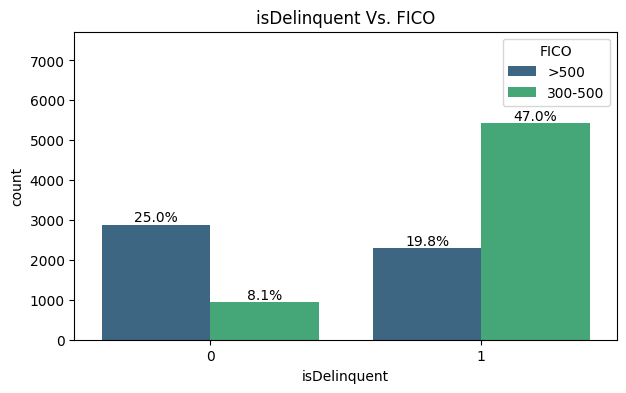

,isDelinquent,FICO,Percentage
0,0,300-500,0.08149
1,0,>500,0.24991
2,1,300-500,0.47012
3,1,>500,0.19848


In [238]:
bargraph_plot(df, 'isDelinquent', 'FICO')

- Those borrowers are on high risk delinquent category whoes FICO score range in 300-500 (47%)

- Here we can see, whoes FICO score >500 the chances of delinquency is decreses quite a lot compaired to when delinquency is between 300-500.

**Let's check weather FICO is impacting on gender, loan purpose, home ownership & age**

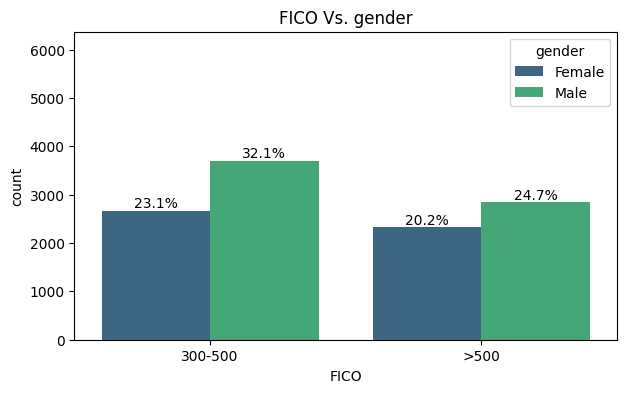

,FICO,gender,Percentage
0,300-500,Female,0.23078
1,300-500,Male,0.32083
2,>500,Female,0.20159
3,>500,Male,0.24680


In [239]:
bargraph_plot(df, 'FICO', 'gender')

* In range 300-500 FICO score, shows Male category is on higher side rather than female category.
* Also, Male category is on high side compair to Female category whoes FICO score > 500.

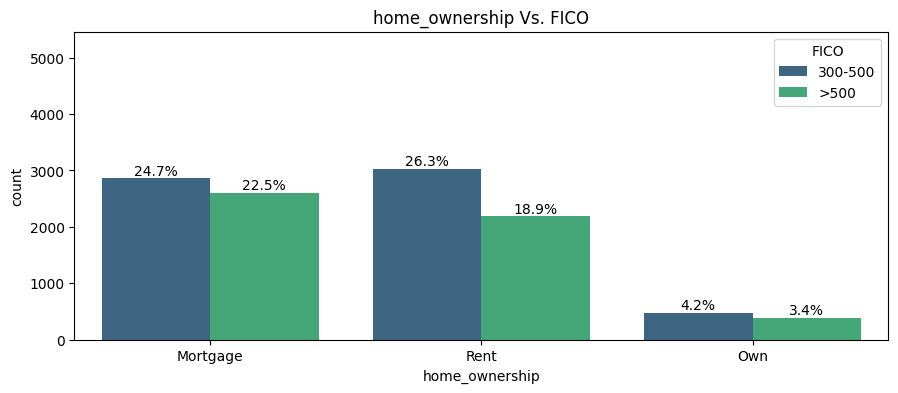

,home_ownership,FICO,Percentage
0,Mortgage,300-500,0.24740
1,Mortgage,>500,0.22549
2,Own,300-500,0.04157
3,Own,>500,0.03386
4,Rent,300-500,0.26264
5,Rent,>500,0.18904


In [240]:
bargraph_plot(df, 'home_ownership', 'FICO')

* In each home Ownership Category, those customers is on higher side whoes FICO score is between the range 300-500.
* It seems like, those whoes FICO score is < 500 those are risky borrowers.

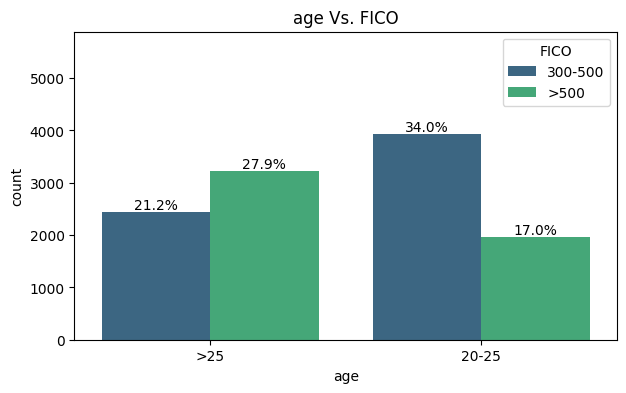

,age,FICO,Percentage
0,20-25,300-500,0.34006
1,20-25,>500,0.16981
2,>25,300-500,0.21155
3,>25,>500,0.27858


In [241]:
bargraph_plot(df, 'age', 'FICO')

* Those Whoe's age is > 25, borrowers FICO score is > 500. But those who are in age range between 20-25 those borrowers score is ranges between 300-500.

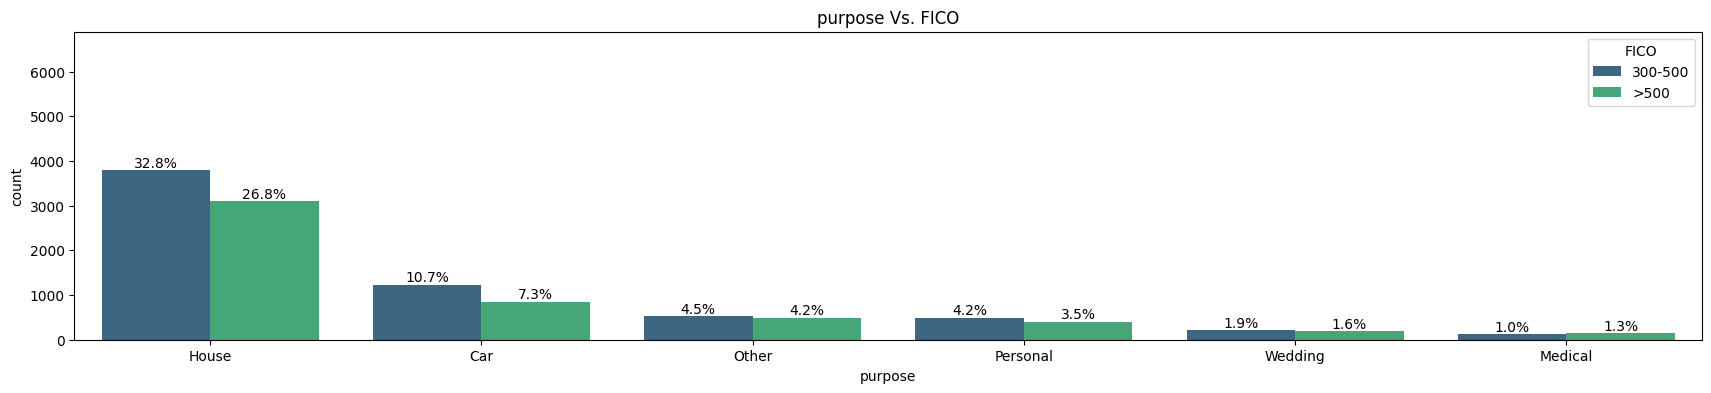

,purpose,FICO,Percentage
0,Car,300-500,0.10677
1,Car,>500,0.07335
2,House,300-500,0.32837
3,House,>500,0.26844
4,Medical,300-500,0.01013
5,Medical,>500,0.01290
6,Other,300-500,0.04503
7,Other,>500,0.04243
8,Personal,300-500,0.04243
9,Personal,>500,0.03481


In [242]:
bargraph_plot(df, 'purpose', 'FICO')

* Those borrower's was took loan for House & car Purposes those FICO score is ranges between 300-500, risky borrowers.

## From This above observation of grpahs on FICO Vs ( Gender, Purpose, Home Ownership, Age ), indicating this might be impacting on delienqucy.

So, we are going to check statistical significance between them to identify correlation

To check this, we can use **Chi-Square test to determine statistical significance** in the association between two categorical varibales.

- Why Chi-square test, Because **Chi-Square Test is very imprtant for categorical data analysis.**

**- It is used to check weather two variable are realted or independent.**

**The Chi-Square test is used to determine whether there is a significant association between two categorical variables. It compares observed frequencies with expected frequencies under the assumption of independence. If the p-value is less than 0.05, we reject the null hypothesis and conclude that the variables are related.**

**Considering the Hypothisis**

* **Null Hypothesis -** There is no correlation between two varibales.(Hn)
* **Alternative Hypothesis -** There is a correlation between two variables (Ha)

### **Statistical Significant Hypothesis Test (Chi-Square) : FICO Vs. Gender**

In [243]:
# contingency table of FICO and gender attributes
crosstab_1 = pd.crosstab(df['FICO'], df['gender'])
print(crosstab_1.reset_index())

gender     FICO  Female  Male
0       300-500    2665  3705
1          >500    2328  2850


In [244]:
# Null Hypothesis
Hn = "FICO score has no effect on gender"

# Alternative Hypothesis
Ha = "FICO Score has an effect on gender"

# Chi-Square test

chi, p_value, dof, expected = stats.chi2_contingency(crosstab_1)

print(f"Observation Table = \n{crosstab_1.reset_index()}\n")
print(f"Expected Table = \n\n{expected.round(2)}\n")
print(f"Chi-square Test Score = {chi.round(3)}\n")
print(f"Degree of Freedom = {dof}\n")
print(f"P-Value = {p_value.round(3)}\n")

if p_value < 0.05 :
  print(f"{Ha} as the p_value {p_value.round(2)} < 0.05")
else :
  print(f"{Hn} as the p_value {p_value.round(2)} > 0.05")

Observation Table = 
gender     FICO  Female  Male
0       300-500    2665  3705
1          >500    2328  2850

Expected Table = 

[[2754.19 3615.81]
 [2238.81 2939.19]]

Chi-square Test Score = 11.222

Degree of Freedom = 1

P-Value = 0.001

FICO Score has an effect on gender as the p_value 0.0 < 0.05


### **Statistical Significant Hypothesis Test (Chi-Square) : FICO Vs. purpose**

In [245]:
crosstab_2 = pd.crosstab(df['FICO'], df['purpose'])
crosstab_2.reset_index()

purpose,FICO,Car,House,Medical,Other,Personal,Wedding
0,300-500,1233,3792,117,520,490,218
1,>500,847,3100,149,490,402,190


In [246]:
# Null Hypothesis
Hn = "FICO score has no effect on purpose"

# Alternative Hypothesis
Ha = "FICO Score has an effect on purpose"

# Chi-Square Test
chi, p_value, dof, expected = stats.chi2_contingency(crosstab_2)

print(f"Observation Table = \n{crosstab_2.reset_index()}\n")
print(f"Expected Table = \n\n{expected.round(2)}\n")
print(f"Chi-square Test Score = {chi.round(3)}\n")
print(f"Degree of Freedom = {dof}\n")
print(f"P-Value = {p_value.round(4)}\n")

if p_value < 0.05 :
  print(f"{Ha} as the p_value {p_value.round(2)} < 0.05")
else :
  print(f"{Hn} as the p_value {p_value.round(2)} > 0.05")

Observation Table = 
purpose     FICO   Car  House  Medical  Other  Personal  Wedding
0        300-500  1233   3792      117    520       490      218
1           >500   847   3100      149    490       402      190

Expected Table = 

[[1147.35 3801.7   146.73  557.13  492.04  225.06]
 [ 932.65 3090.3   119.27  452.87  399.96  182.94]]

Chi-square Test Score = 33.778

Degree of Freedom = 5

P-Value = 0.0

FICO Score has an effect on purpose as the p_value 0.0 < 0.05


#### **Statistical Significant Hypothesis Test (Chi-Square) : FICO Vs. home_ownership**

In [247]:
crosstab_3 = pd.crosstab(df['FICO'], df['home_ownership'])
print(crosstab_3.reset_index())

home_ownership     FICO  Mortgage  Own  Rent
0               300-500      2857  480  3033
1                  >500      2604  391  2183


In [248]:
# Null Hypothesis
Hn = "FICO score has no effect on home_ownership"

# Alternative Hypothesis
Ha = "FICO Score has an effect on home_ownership"

# chi-square test
chi, p_value, dof, expected = stats.chi2_contingency(crosstab_3)

print(f"Observation Table = \n{crosstab_3.reset_index()}\n")
print(f"Expected Table = \n\n{expected.round(2)}\n")
print(f"Chi-square Test Score = {chi.round(3)}\n")
print(f"Degree of Freedom = {dof}\n")
print(f"P-Value = {p_value.round(4)}\n")

if p_value < 0.05 :
  print(f"{Ha} as the p_value {p_value.round(2)} < 0.05")
else :
  print(f"{Hn} as the p_value {p_value.round(2)} > 0.05")

Observation Table = 
home_ownership     FICO  Mortgage  Own  Rent
0               300-500      2857  480  3033
1                  >500      2604  391  2183

Expected Table = 

[[3012.35  480.45 2877.2 ]
 [2448.65  390.55 2338.8 ]]

Chi-square Test Score = 36.682

Degree of Freedom = 2

P-Value = 0.0

FICO Score has an effect on home_ownership as the p_value 0.0 < 0.05


### **Statistical Significant Hypothesis Test (Chi-Square) : FICO Vs. age**

In [249]:
crosstab_4 = pd.crosstab(df['FICO'], df['age'])
print(crosstab_4.reset_index())

age     FICO  20-25   >25
0    300-500   3927  2443
1       >500   1961  3217


In [250]:
# Null Hypothesis
Hn = "FICO score has no effect on home_ownership"

# Alternative Hypothesis
Ha = "FICO Score has an effect on home_ownership"

# chi-square test
chi, p_value, dof, expected = stats.chi2_contingency(crosstab_4)

print(f"Observation Table = \n{crosstab_4.reset_index()}\n")
print(f"Expected Table = \n\n{expected.round(2)}\n")
print(f"Chi-square Test Score = {chi.round(3)}\n")
print(f"Degree of Freedom = {dof}\n")
print(f"P-Value = {p_value.round(4)}\n")

if p_value < 0.05 :
  print(f"{Ha} as the p_value {p_value.round(2)} < 0.05")
else :
  print(f"{Hn} as the p_value {p_value.round(2)} > 0.05")

Observation Table = 
age     FICO  20-25   >25
0    300-500   3927  2443
1       >500   1961  3217

Expected Table = 

[[3247.88 3122.12]
 [2640.12 2537.88]]

Chi-square Test Score = 645.184

Degree of Freedom = 1

P-Value = 0.0

FICO Score has an effect on home_ownership as the p_value 0.0 < 0.05


from the above all Chi-square test on FICO Score Vs. age, gender, purpose, home ownership has p-value < 0.01. all plots are statistically significant.

* There is a correlation between FICO & gender. More Femals have FICO > 500 as copaired to Male.

* There is a correlation between FICO & purpose. for all the purpose except Medical purpose has all purpose FICO score ranges 300-500 borrowers.

* There is a correlation between FICO & home_ownership. for Mortages & rents home status borrowers have FICO score > 500.

* There is a correlation between FICO & age. those whoes age > 25 those borrowers FICO score is high.

## **Data Preprocessing**

**Data preprocessing for Modeling**

In [251]:
# X & y
X = df.drop(['isDelinquent'], axis = 1)
y = df['isDelinquent']

In [252]:
# Encoding the categorical variables by get_dummies()
X = pd.get_dummies(X, drop_first= True).astype(int)
X.head()

,term_60 months,gender_Male,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Own,home_ownership_Rent,age_>25,FICO_>500
0,0,0,1,0,0,0,0,0,0,1,0
1,0,0,1,0,0,0,0,0,1,0,1
2,0,0,1,0,0,0,0,0,1,1,0
3,0,0,0,0,0,0,0,0,0,1,0
4,0,0,1,0,0,0,0,0,1,1,0


In [253]:
# splitting the data into train & test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=1
)

In [254]:
print(f"No. of rows in train data : {X_train.shape[0]}")
print(f"No. of rows in test data : {X_test.shape[0]}")

No. of rows in train data : 6928
No. of rows in test data : 4620


In [255]:
# checking the splited test data interm of percentage
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

isDelinquent
1   0.67740
0   0.32260
Name: proportion, dtype: float64
isDelinquent
1   0.65541
0   0.34459
Name: proportion, dtype: float64


# **Model Building**

### **Model Evaluation Criterion**

**Model can make wrong predictions as:**

1. Predicting a customer will not be behind on payments (Non-Delinquent) but in reality the customer would be behind on payments.

2. Predicting a customer will be behind on payments (Delinquent) but in reality the customer would not be behind on payments (Non-Delinquent).

**Which case is more important?**

* If we predict a non-delinquent customer as a delinquent customer bank would lose an opportunity of providing loan to a potential customer.

**How to reduce this loss i.e need to reduce False Negatives?**

* recall should be maximized, the greater the recall higher the chances of minimizing the false negatives.

**First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.**

* The model_performance_classification_sklearn function will be used to check the model performance of models.
* The make_confusion_matrix function will be used to plot confusion matrix.

In [256]:
try :
  # ploting a confusion matrics
  def plot_confusion_matrics(model, predictor, target):

    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictor)

    # Compute the confusion matrix compairing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    TN = cm[0,0]
    FP = cm[0,1]
    FN = cm[1,0]
    TP = cm[1,1]

    cm_df = pd.DataFrame({
        "True Negative" : TN,
        "False Positive" : FP,
        "False Negative" : FN,
        "True Positive" : TP
    }, index = [0]).reset_index(drop=True)

    # create a labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format( item / cm.flatten().sum()) for item in cm.flatten()]
        ]
    ).reshape(2, 2)

    plt.figure(figsize = (4,3))

    sns.heatmap(cm, annot = labels, cmap = 'Spectral', fmt = "")

    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")

    return cm_df

  print("Function defined")
except Exception as e :
  print(f"Model Not defined {e}")

Function defined


In [257]:
# definfing a function to compute different matrics to check performance of a classification model building
try :
  def model_performance_classification(model, preictors, target):
    # predicting independent variables
    y_pred = model.predict(preictors)

    # to compute accuracy
    acc_score = accuracy_score(target, y_pred)
    # to compute recall
    recall = recall_score(target, y_pred)
    # to compute precision
    precision = precision_score(target, y_pred)
    # to compute f1 score
    f1 = f1_score(target, y_pred)

    # creating a df for this matrics

    df_pred = pd.DataFrame({
        "Accuracy": acc_score,
        "Recall" : recall,
        "Precision" : precision,
        "F1" : f1
    }, index = [0])

    return df_pred
  print("Function Defined")
except Exception as r :
  print(f"FUnction not defined, {r}")

Function Defined


In [258]:
def classification_matrics(model, predicator, target):
  # prediction variable
  pred = model.predict(predicator)

  # confusion matrics
  cm = confusion_matrix(target, pred)
  error_rate = (cm[1,0]+ cm[0,1]) / (cm[0,0] + cm[0,1] + cm[1,0] + cm[1,1])

  # evaluation matrics
  acc = accuracy_score(target, pred)
  prec = precision_score(target, pred)
  recal = recall_score(target, pred)
  f1 = f1_score(target, pred)

  # keeping all matrics in one single df
  evaluation_df = pd.DataFrame({
      "Accuracy" : acc,
      "Precision" : prec,
      "Recall" : recal,
      "F1-Score" : f1,
      "Error Rate" : error_rate
  }, index = [0])

  return evaluation_df

## **Building Decision Tree (Default)**

In [259]:

# defing the model variable
# in deafult criterion = 'gini'
dtree = DecisionTreeClassifier(criterion = 'gini', random_state=1)

In [260]:
# fitting the data into model
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,1662,573,428,4265


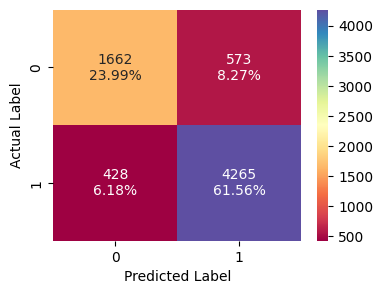

In [261]:
# Checking mdoel performance on train data

# Checking Confusin matrics on train data
plot_confusion_matrics(dtree, X_train, y_train)

In [262]:
default_param_model_evaluation_train_data = classification_matrics(dtree, X_train, y_train)
default_param_model_evaluation_train_data

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.85551,0.88156,0.90880,0.89497,0.14449


,True Negative,False Positive,False Negative,True Positive
0,1181,411,311,2717


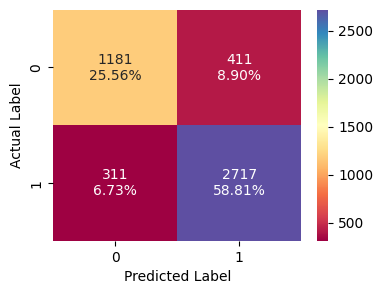

In [263]:
# checking model performance on test data

# confusion matrics on test data
plot_confusion_matrics(dtree,X_test, y_test)

In [264]:
default_param_model_evaluation_test_data = classification_matrics(dtree, X_test, y_test)
default_param_model_evaluation_test_data

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.84372,0.86861,0.89729,0.88272,0.15628


In [265]:
display("Performance matrics on Train data")
print(f"\n{default_param_model_evaluation_train_data}\n")
display("Performance matrics on Test data")
print(f"\n{default_param_model_evaluation_test_data}\n")

'Performance matrics on Train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.85551    0.88156 0.90880   0.89497     0.14449



'Performance matrics on Test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.84372    0.86861 0.89729   0.88272     0.15628



**Ap per the above model performance summary**
* based on train & test Data, our model **accuracy** is on train data 0.86 & Test data 0.84.
* **Precision** in on Train data 0.88 & 0.87 is on test data.
* **Recall** is on Train data 0.91 & 0.90 is on test data.
* **F-1 Score** on train data is 0.89 & 0.88 is on test data.

> **Overall our model performing well on both the dataset (Train & test).**

### **Visualizing the Decision Tree**

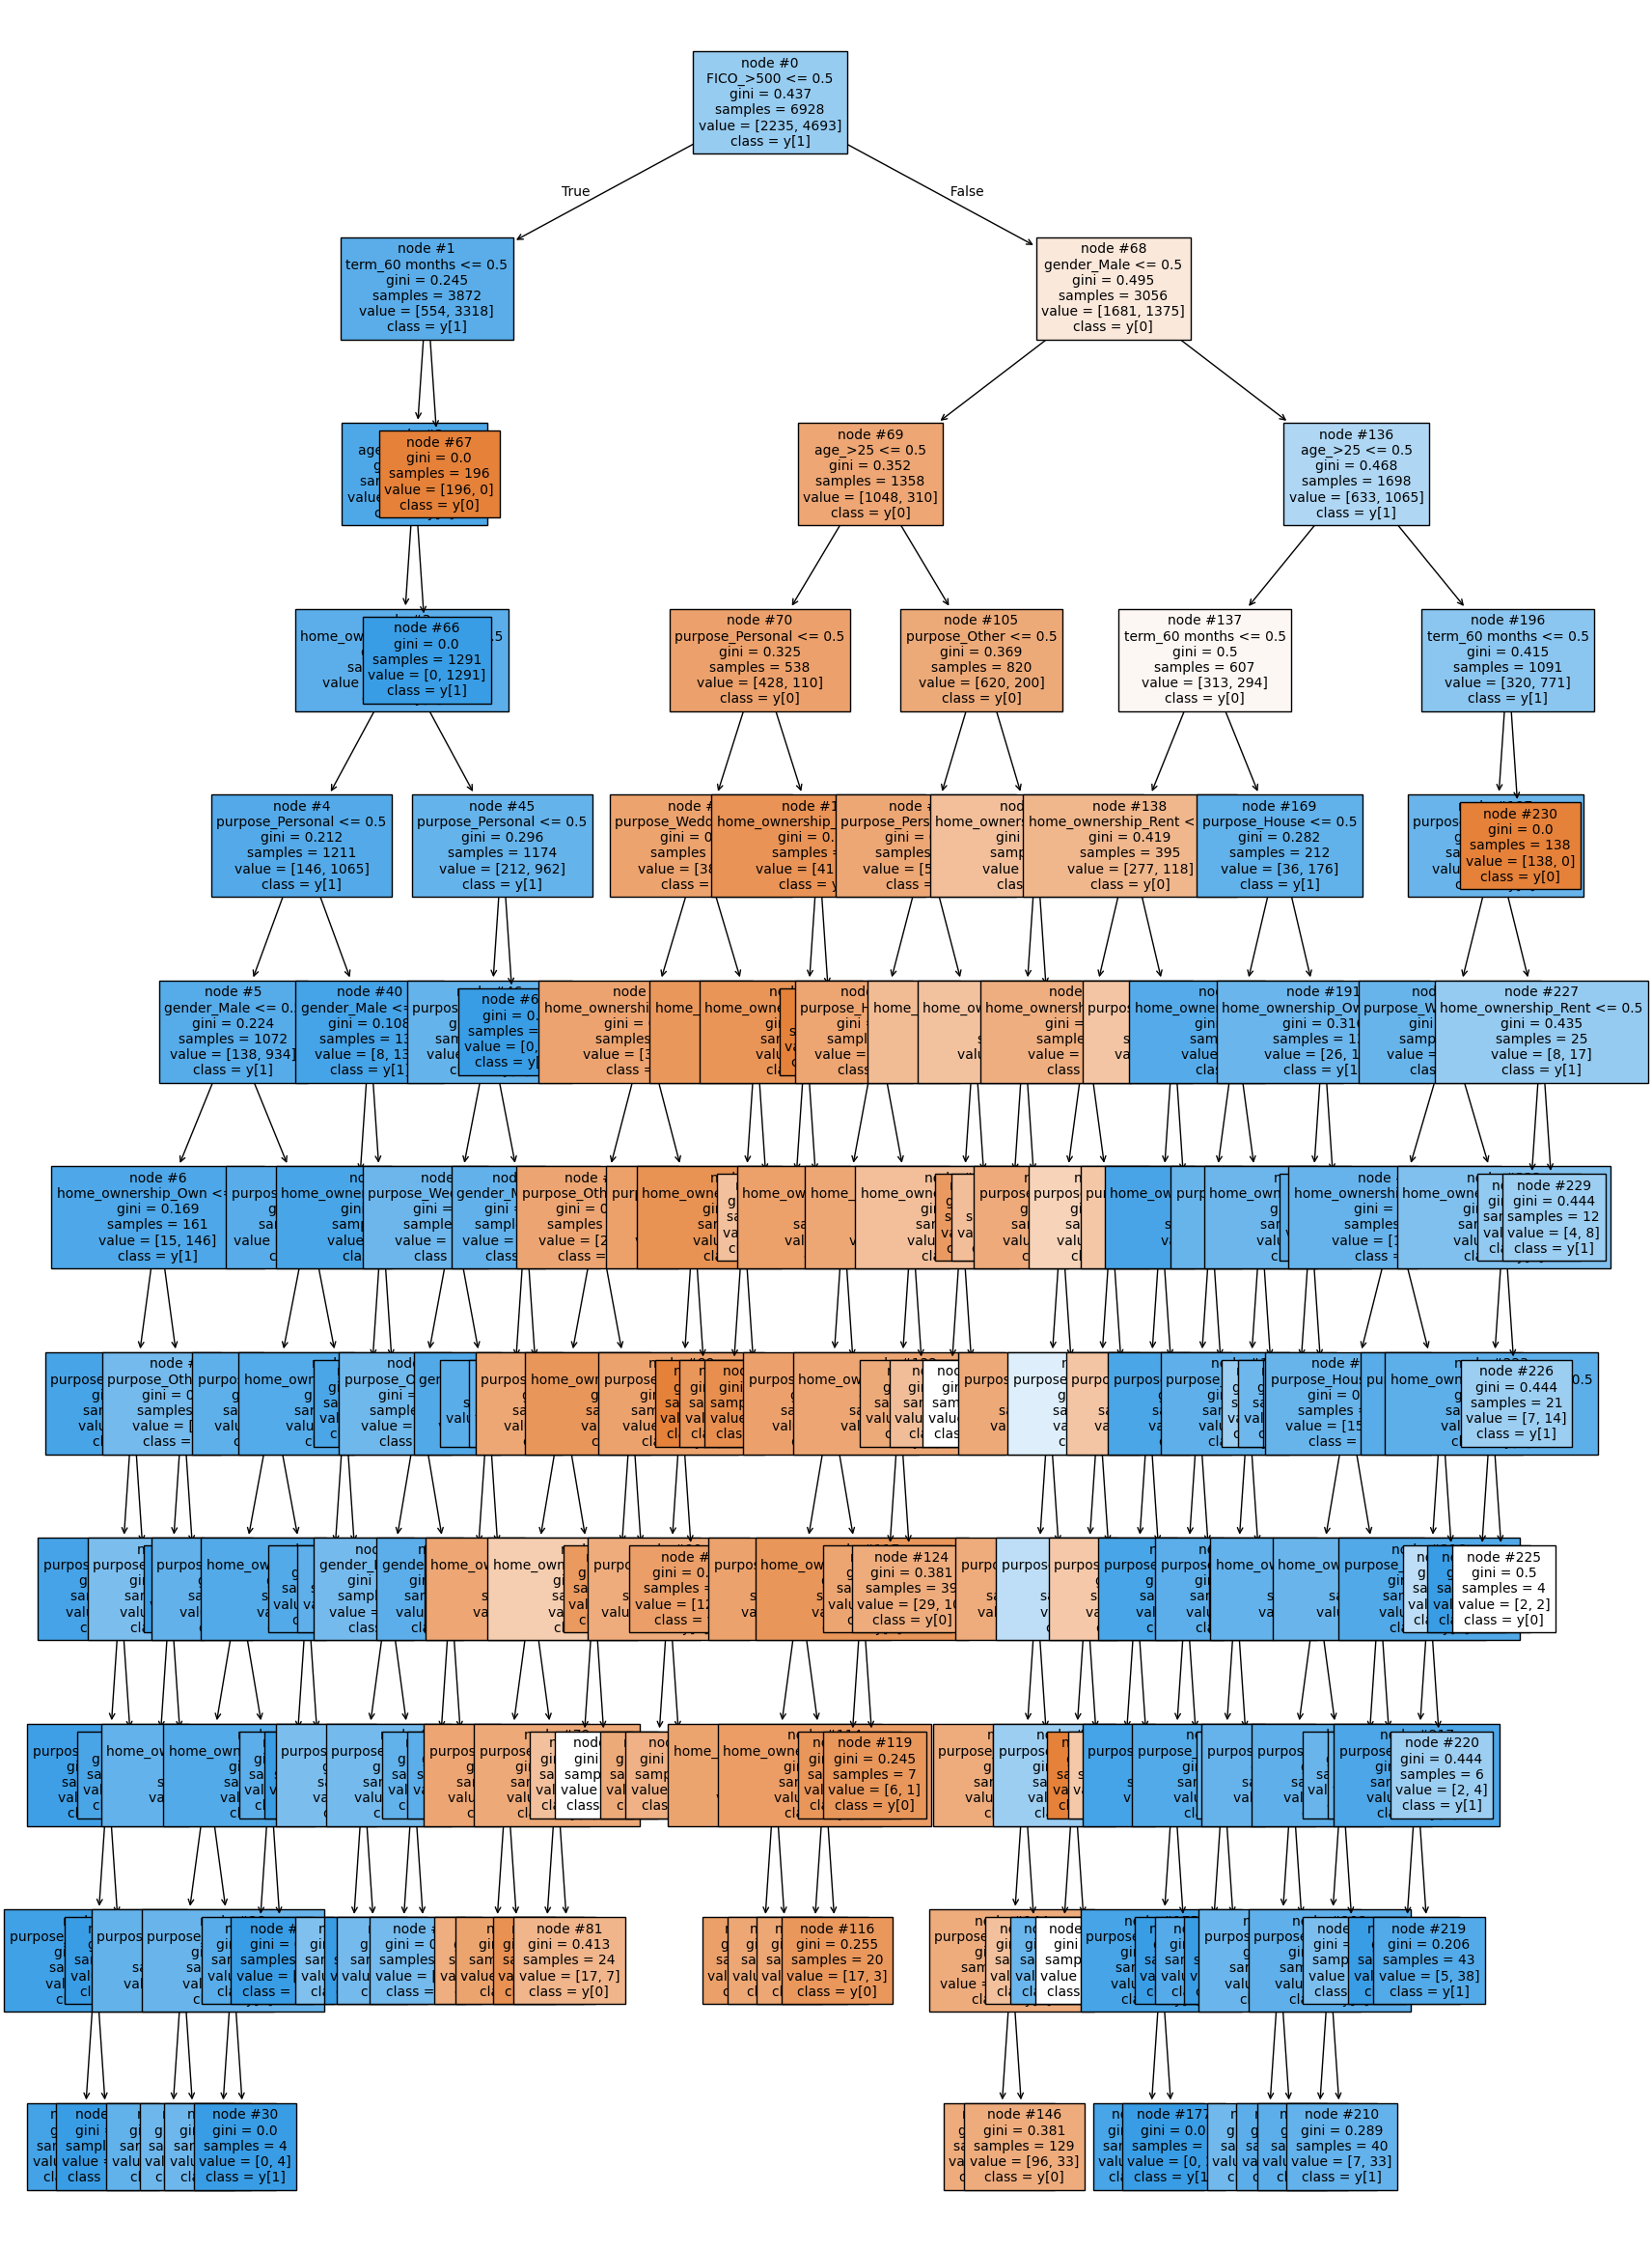

In [266]:
# column names
feature_name = X.columns.tolist()

# plotting Decision tree

# figure size
plt.figure(figsize = (20,30))

plot = tree.plot_tree(
    dtree,   # model name
    feature_names = feature_name ,  # column names
    filled = True,
    fontsize = 10,
    node_ids = True,
    class_names = True
)

# if by chance arrow will not print then below code will help to print arrows

# for a in plot :
#   arrow = a.arrow_patch
#   if arrow is not None :
#     arrow.set_edgcolor("black")
#     arrow.set_linewidth(1)
# plt.show()

In [267]:
# Text report showing the rules of a decision tree -

tree_text = tree.export_text(
    dtree,
    feature_names = feature_name,
    show_weights = True
)

print(tree_text)

|--- FICO_>500 <= 0.50
|   |--- term_60 months <= 0.50
|   |   |--- age_>25 <= 0.50
|   |   |   |--- home_ownership_Rent <= 0.50
|   |   |   |   |--- purpose_Personal <= 0.50
|   |   |   |   |   |--- gender_Male <= 0.50
|   |   |   |   |   |   |--- home_ownership_Own <= 0.50
|   |   |   |   |   |   |   |--- purpose_Medical <= 0.50
|   |   |   |   |   |   |   |   |--- purpose_House <= 0.50
|   |   |   |   |   |   |   |   |   |--- purpose_Other <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- purpose_Wedding <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [1.00, 18.00] class: 1
|   |   |   |   |   |   |   |   |   |   |--- purpose_Wedding >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 9.00] class: 1
|   |   |   |   |   |   |   |   |   |--- purpose_Other >  0.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 14.00] class: 1
|   |   |   |   |   |   |   |   |--- purpose_House >  0.50
|   |   |   |   |   |   |   |   |   |--- weight

## **Feature Importance on Default Parameter Decision Tree**

In [268]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : dtree.feature_importances_.round(3)
}).sort_values(by = ['Importance'], ascending = False).reset_index(drop=True)

print(feature_importance)

                Feature  Importance
0             FICO_>500     0.38800
1        term_60 months     0.36900
2           gender_Male     0.16500
3               age_>25     0.05300
4    home_ownership_Own     0.00500
5   home_ownership_Rent     0.00500
6      purpose_Personal     0.00400
7         purpose_House     0.00300
8         purpose_Other     0.00300
9       purpose_Wedding     0.00200
10      purpose_Medical     0.00200


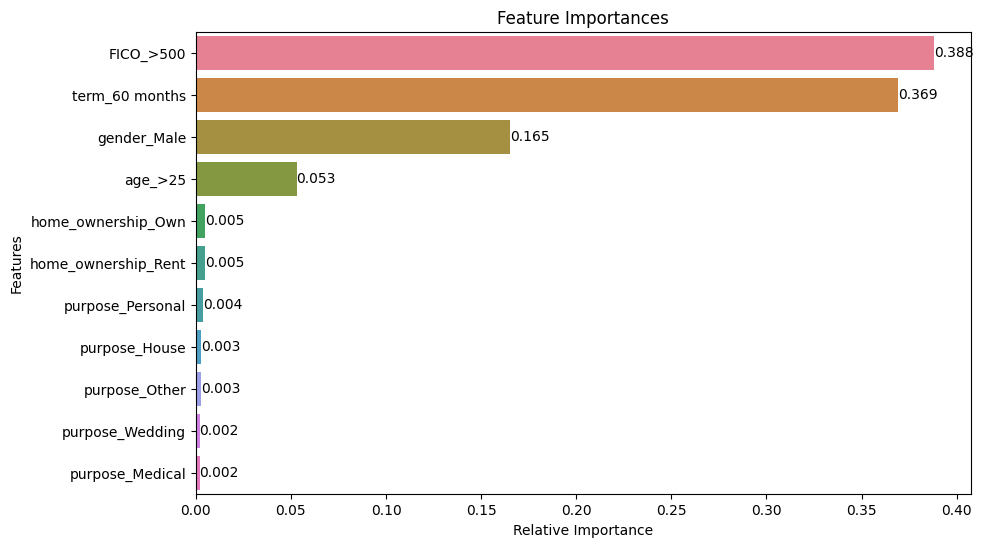

In [269]:
# plotting this above importance values in graph
plt.figure(figsize = (10,6))
plt.title("Feature Importances")
plot_1 = sns.barplot(feature_importance, x = 'Importance', y = 'Feature', hue = 'Feature')
plt.xlabel("Relative Importance")
plt.ylabel("Features")

for value in plot_1.containers:
  plot_1.bar_label(value)

plt.show()

**FICO, Loan Term duration, Gender are the top 3 Importance Feature.**

### **Decision Tree (Pre-pruning)**

**Hyperparameter Tuning**

* Hyperparameter tuning is crucial because it directly affects the performance of a model.
* Unlike model parameters which are learned during training, hyperparameters need to be set before training.
* Effective hyperparameter tuning helps in improving the performance and robustness of the model.
* The below custom loop for hyperparameter tuning iterates over predefined parameter values to identify the best model based on the metric of choice (recall score).

In [270]:
# defining the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 200]
min_smaple_split_values = [10, 30, 50, 70]

# initializer variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values :
  for max_leaf_nodes in max_leaf_nodes_values :
    for min_samples_split in min_smaple_split_values :

      estimator = DecisionTreeClassifier(
          max_depth = max_depth,
          max_leaf_nodes = max_leaf_nodes,
          min_samples_split = min_samples_split,
          class_weight = 'balanced',
          random_state = 42
      )

      estimator.fit(X_train, y_train)

      y_train_pred = estimator.predict(X_train)
      y_test_pred = estimator.predict(X_test)

      train_recall_score = recall_score(y_train, y_train_pred)
      test_recall_score = recall_score(y_test, y_test_pred)

      score_diff = abs(train_recall_score - test_recall_score)

      # updating the best estimator & best score if the current one has smaller score diff
      if ( score_diff < best_score_diff) & ( test_recall_score > best_test_score ) :
        best_score_diff = score_diff
        best_test_score = test_recall_score
        best_estimator = estimator

dtree1 = best_estimator

print("Best Parameters found")
print(f"Max Depth : {best_estimator.max_depth}")
print(f"Max leaf nodes : {best_estimator.max_leaf_nodes}")
print(f"Min Smaple Split : {best_estimator.min_samples_split}")
print(f"Best Test Recall score : {best_test_score}")

Best Parameters found
Max Depth : 6
Max leaf nodes : 50
Min Smaple Split : 10
Best Test Recall score : 0.8972919418758256


**Checking performance on Train Data**

,True Negative,False Positive,False Negative,True Positive
0,1663,572,436,4257


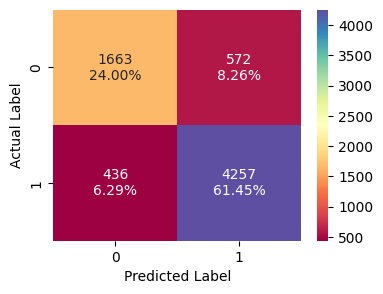

In [271]:
plot_confusion_matrics(best_estimator, X_train, y_train)

In [272]:
pre_prun_model_evaluation_train_data = classification_matrics(best_estimator, X_train, y_train)
pre_prun_model_evaluation_train_data

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.85450,0.88155,0.90710,0.89414,0.14550


**Checking performance on Test Data**

,True Negative,False Positive,False Negative,True Positive
0,1187,405,311,2717


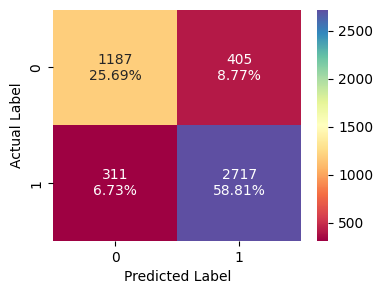

In [273]:
plot_confusion_matrics(best_estimator, X_test, y_test)

In [274]:
pre_prun_model_evaluation_test_data = classification_matrics(best_estimator, X_test, y_test)
pre_prun_model_evaluation_test_data

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.84502,0.87028,0.89729,0.88358,0.15498


In [275]:
display("Pre-Pruned model Performance Evaluation on train data")
print(f"\n{pre_prun_model_evaluation_train_data}\n")
display("Pre-Pruned model Performance Evaluation on test data")
print(f"\n{pre_prun_model_evaluation_test_data}")

'Pre-Pruned model Performance Evaluation on train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.85450    0.88155 0.90710   0.89414     0.14550



'Pre-Pruned model Performance Evaluation on test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.84502    0.87028 0.89729   0.88358     0.15498


After Pr-prunening the model, giving same performance on Train & Test Dataset.
* **Accuracy :** is around 0.85
* **Precision :** is around 0.88 on train & 0.87 on test data.
* **Recall :** is around 0.91 on train & 0.90 on test data

### **Pre-pruned : Decision Tree**

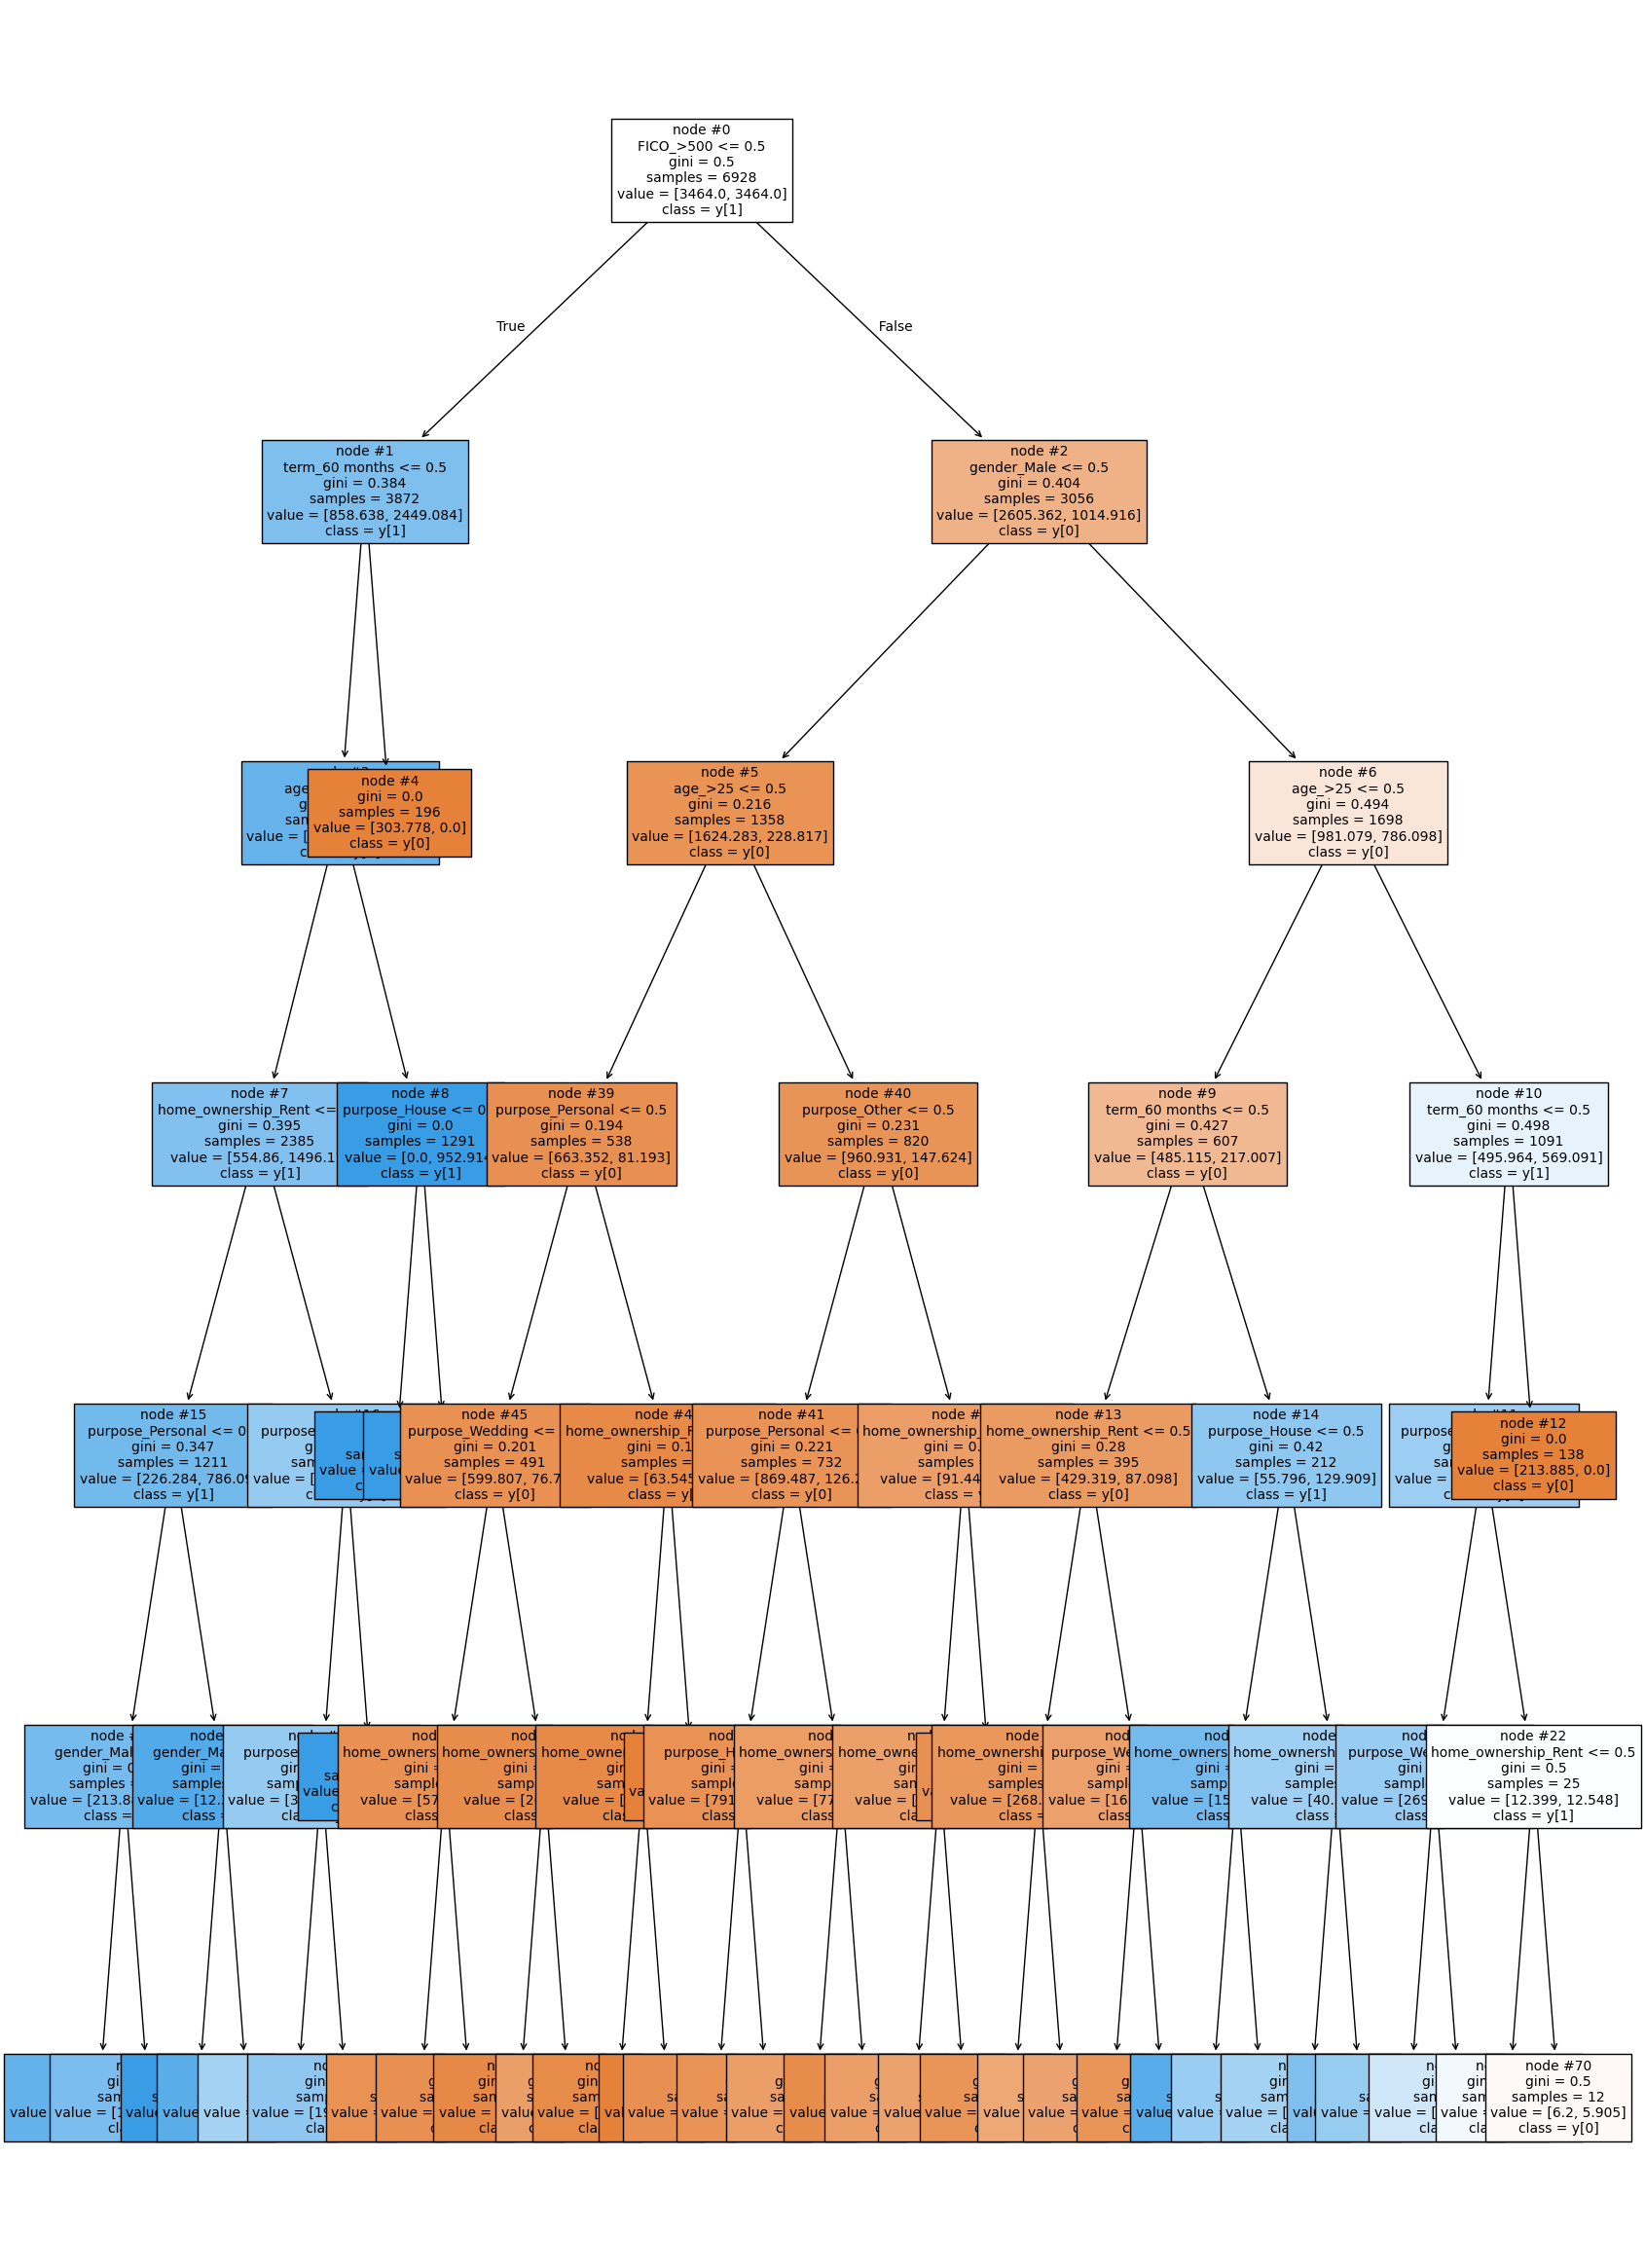

In [276]:
# column names
feature_name = X.columns.tolist()

# plotting Decision tree

# figure size
plt.figure(figsize = (20,30))

plot = tree.plot_tree(
    best_estimator,   # model name
    feature_names = feature_name ,  # column names
    filled = True,
    fontsize = 10,
    node_ids = True,
    class_names = True
)

# if by chance arrow will not print then below code will help to print arrows

# for a in plot :
#   arrow = a.arrow_patch
#   if arrow is not None :
#     arrow.set_edgcolor("black")
#     arrow.set_linewidth(1)
# plt.show()

In [277]:
# decision Tree text
pre_pruned_tree_text = tree.export_text(
    best_estimator,
    feature_names = feature_name,
    show_weights = True
)

print(pre_pruned_tree_text)

|--- FICO_>500 <= 0.50
|   |--- term_60 months <= 0.50
|   |   |--- age_>25 <= 0.50
|   |   |   |--- home_ownership_Rent <= 0.50
|   |   |   |   |--- purpose_Personal <= 0.50
|   |   |   |   |   |--- gender_Male <= 0.50
|   |   |   |   |   |   |--- weights: [23.25, 107.77] class: 1
|   |   |   |   |   |--- gender_Male >  0.50
|   |   |   |   |   |   |--- weights: [190.64, 581.64] class: 1
|   |   |   |   |--- purpose_Personal >  0.50
|   |   |   |   |   |--- gender_Male <= 0.50
|   |   |   |   |   |   |--- weights: [0.00, 19.93] class: 1
|   |   |   |   |   |--- gender_Male >  0.50
|   |   |   |   |   |   |--- weights: [12.40, 76.76] class: 1
|   |   |   |--- home_ownership_Rent >  0.50
|   |   |   |   |--- purpose_Personal <= 0.50
|   |   |   |   |   |--- purpose_House <= 0.50
|   |   |   |   |   |   |--- weights: [130.19, 242.84] class: 1
|   |   |   |   |   |--- purpose_House >  0.50
|   |   |   |   |   |   |--- weights: [198.39, 459.11] class: 1
|   |   |   |   |--- purpose_Persona

### **Feature Importance**

In [303]:
feature_importance_pre_pruned = pd.DataFrame({
    "Features" : X.columns,
    "Importance" : best_estimator.feature_importances_.round(4)
}).sort_values(by = ['Importance'], ascending = False).reset_index(drop=True)

print(feature_importance_pre_pruned)

               Features  Importance
0             FICO_>500     0.43590
1        term_60 months     0.35540
2           gender_Male     0.11230
3               age_>25     0.08260
4   home_ownership_Rent     0.00660
5      purpose_Personal     0.00330
6         purpose_House     0.00130
7       purpose_Medical     0.00080
8    home_ownership_Own     0.00070
9       purpose_Wedding     0.00060
10        purpose_Other     0.00050


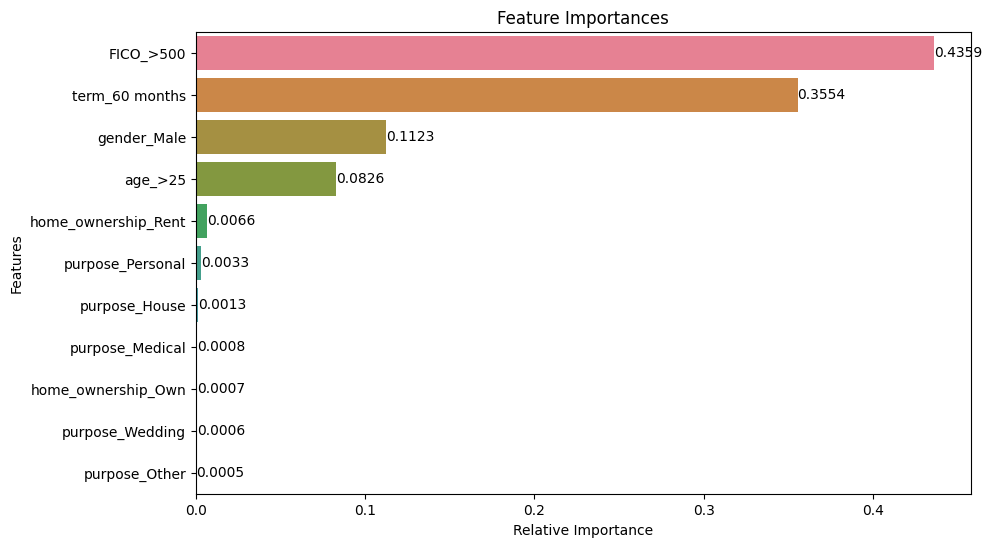

In [304]:
# plotting this above importance values in graph
plt.figure(figsize = (10,6))
plt.title("Feature Importances")
plot_2 = sns.barplot(feature_importance_pre_pruned, x = 'Importance', y = 'Features', hue = 'Features')
plt.xlabel("Relative Importance")
plt.ylabel("Features")

for value in plot_2.containers:
  plot_2.bar_label(value)

plt.show()

### **Decision Tree (Post-pruning)**

* Cost Complexity pruning provides another option to constrol the size of a tree.

* In **DecisionTreeClassifier** , this pruning techniques is paramterized by CCP_alpha ( Cost Complexity Parameter )

In [305]:
# Train a Full Tree
clf = DecisionTreeClassifier(random_state =42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

**now we have ccp_alphas**

In [306]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.00000,0.22640
1,0.00000,0.22640
2,0.00000,0.22640
3,0.00000,0.22640
4,0.00000,0.22640
...,...,...
80,0.01125,0.24862
81,0.01417,0.27696
82,0.03467,0.31163
83,0.04376,0.35539


In [329]:
# train the decision tree using effective alphas

clfs = []

for ccp_alpha in ccp_alphas :
  clf = DecisionTreeClassifier(random_state = 1, ccp_alpha = ccp_alpha)
  clf.fit(X_train, y_train)
  clfs.append(clf)

print(f"Number of nodes in last tree {clfs[-1].tree_.node_count} with ccp_alpha {ccp_alphas[-1]}")


Number of nodes in last tree 1 with ccp_alpha 0.08167024657332106


In [338]:
# in this list we have multiple decision tree with there ccp_alpha values
clfs

[DecisionTreeClassifier(ccp_alpha=np.float64(0.0), random_state=1),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0), random_state=1),
 DecisionTreeClassifier(ccp_alpha=np.float64(2.794667880792745e-09),
                        random_state=1),
 DecisionTreeClassifier(ccp_alpha=np.float64(2.2449843201793884e-07),
                        random_state=1),
 DecisionTreeClassifier(ccp_alpha=np.float64(4.918264264568151e-07),
                        random_state=1),
 DecisionTreeClassifier(ccp_alpha=np.float64(6.998390370215567e-07),
                        random_state=1),
 DecisionTreeClassifier(ccp_alpha=np.float64(7.597561064321551e-07),
                        random_state=1),
 DecisionTreeClassifier(ccp_alpha=np.float64(1.0588739079134442e-06),
                        random_state=1),
 DecisionTreeClassifier(ccp_alpha=np.float64(1.1843429857287882e-06),
                        random_state=1),
 DecisionTreeClassifier(ccp_alpha=np.float64(1.3861188944749164e-06),
                     

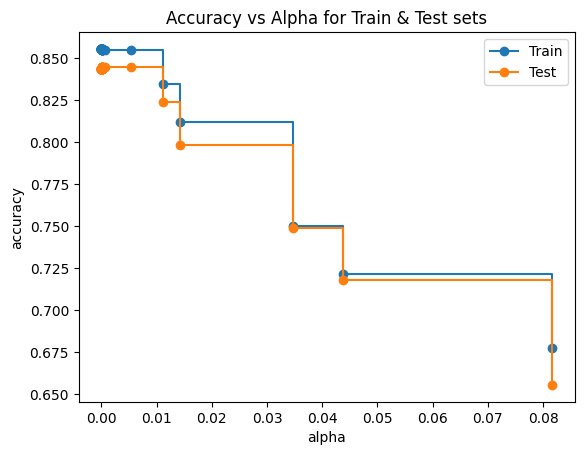

In [309]:
# now we are going to check & plot the score on train & test data set

train_accuracy_score = []
for clf in clfs :
  pred_train = clf.predict(X_train)
  accuracy_train_value = accuracy_score(y_train, pred_train)
  train_accuracy_score.append(accuracy_train_value)


test_accuracy_score = []
for clf in clfs :
  pred_test = clf.predict(X_test)
  accuracy_test_value = accuracy_score(y_test, pred_test)
  test_accuracy_score.append(accuracy_test_value)

fig, ax = plt.subplots()

ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs Alpha for Train & Test sets")

ax.plot(ccp_alphas, train_accuracy_score, marker = "o", label = "Train", drawstyle = "steps-post")
ax.plot(ccp_alphas, test_accuracy_score, marker = "o", label = "Test", drawstyle = "steps-post")

ax.legend()
plt.show()

In [330]:
# now we are checking the recall for train & test data
recall_train = []

for clf in clfs :
  pred_train = clf.predict(X_train)
  values_train = recall_score(y_train, pred_train)
  recall_train.append(values_train)


recall_test = []

for clf in clfs :
  pred_test = clf.predict(X_test)
  values_test = recall_score(y_test, pred_test)
  recall_test.append(values_test)

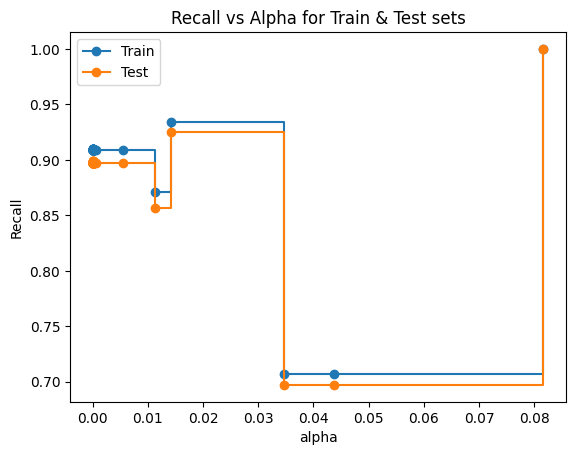

In [332]:
fig, ax = plt.subplots()

ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs Alpha for Train & Test sets")

ax.plot(ccp_alphas, recall_train, marker = "o", label = "Train", drawstyle = "steps-post")
ax.plot(ccp_alphas, recall_test, marker = "o", label = "Test", drawstyle = "steps-post")

ax.legend()
plt.show()

In [333]:
# creating the model where we get the highest train & test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.08167024657332106),
                       random_state=1)


In [335]:
# now we are checking the recall for train & test data
f1_train = []

for clf in clfs :
  pred_train = clf.predict(X_train)
  values_train = f1_score(y_train, pred_train)
  f1_train.append(values_train)


f1_test = []

for clf in clfs :
  pred_test = clf.predict(X_test)
  values_test = f1_score(y_test, pred_test)
  f1_test.append(values_test)

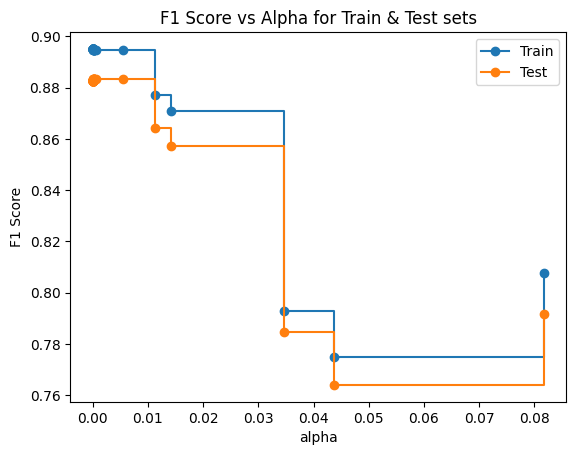

In [336]:
fig, ax = plt.subplots()

ax.set_xlabel("alpha")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs Alpha for Train & Test sets")

ax.plot(ccp_alphas, f1_train, marker = "o", label = "Train", drawstyle = "steps-post")
ax.plot(ccp_alphas, f1_test, marker = "o", label = "Test", drawstyle = "steps-post")

ax.legend()
plt.show()

In [372]:
# creating the model where we get the highest train & test recall
index_best_model = np.argmax(test_accuracy_score)
dtree3 = DecisionTreeClassifier(ccp_alpha =0.007, random_state=1 )   # model defining
dtree3.fit(X_train, y_train)
print(dtree3)

DecisionTreeClassifier(ccp_alpha=0.007, random_state=1)


In [373]:
# so finally we are going to build a model
dtree3

DecisionTreeClassifier(ccp_alpha=0.007, random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,1659,576,428,4265


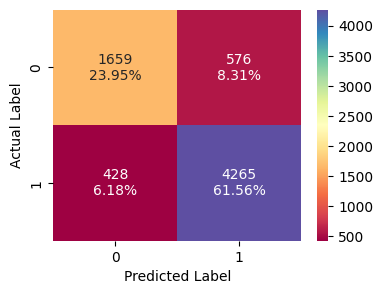

In [374]:
plot_confusion_matrics(dtree3, X_train, y_train)

In [375]:
post_prun_model_evaluation_train_data = classification_matrics(dtree3, X_train, y_train)
post_prun_model_evaluation_train_data

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.85508,0.88102,0.90880,0.89469,0.14492


,True Negative,False Positive,False Negative,True Positive
0,1185,407,310,2718


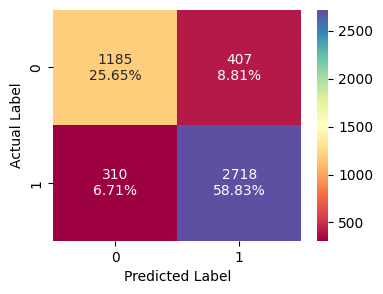

In [376]:
plot_confusion_matrics(dtree3, X_test, y_test)

In [377]:
post_prun_model_evaluation_test_data = classification_matrics(dtree3, X_test, y_test)
post_prun_model_evaluation_test_data

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.84481,0.86976,0.89762,0.88347,0.15519


In [378]:
display("Pre-Pruned model Performance Evaluation on train data")
print(f"\n{post_prun_model_evaluation_train_data}\n")
display("Pre-Pruned model Performance Evaluation on test data")
print(f"\n{post_prun_model_evaluation_test_data}")

'Pre-Pruned model Performance Evaluation on train data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.85508    0.88102 0.90880   0.89469     0.14492



'Pre-Pruned model Performance Evaluation on test data'


   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.84481    0.86976 0.89762   0.88347     0.15519


After Post-Pruned,
Our Model Recall on train data is around 0.91 & recall on test data around 0.90. which is good indication.

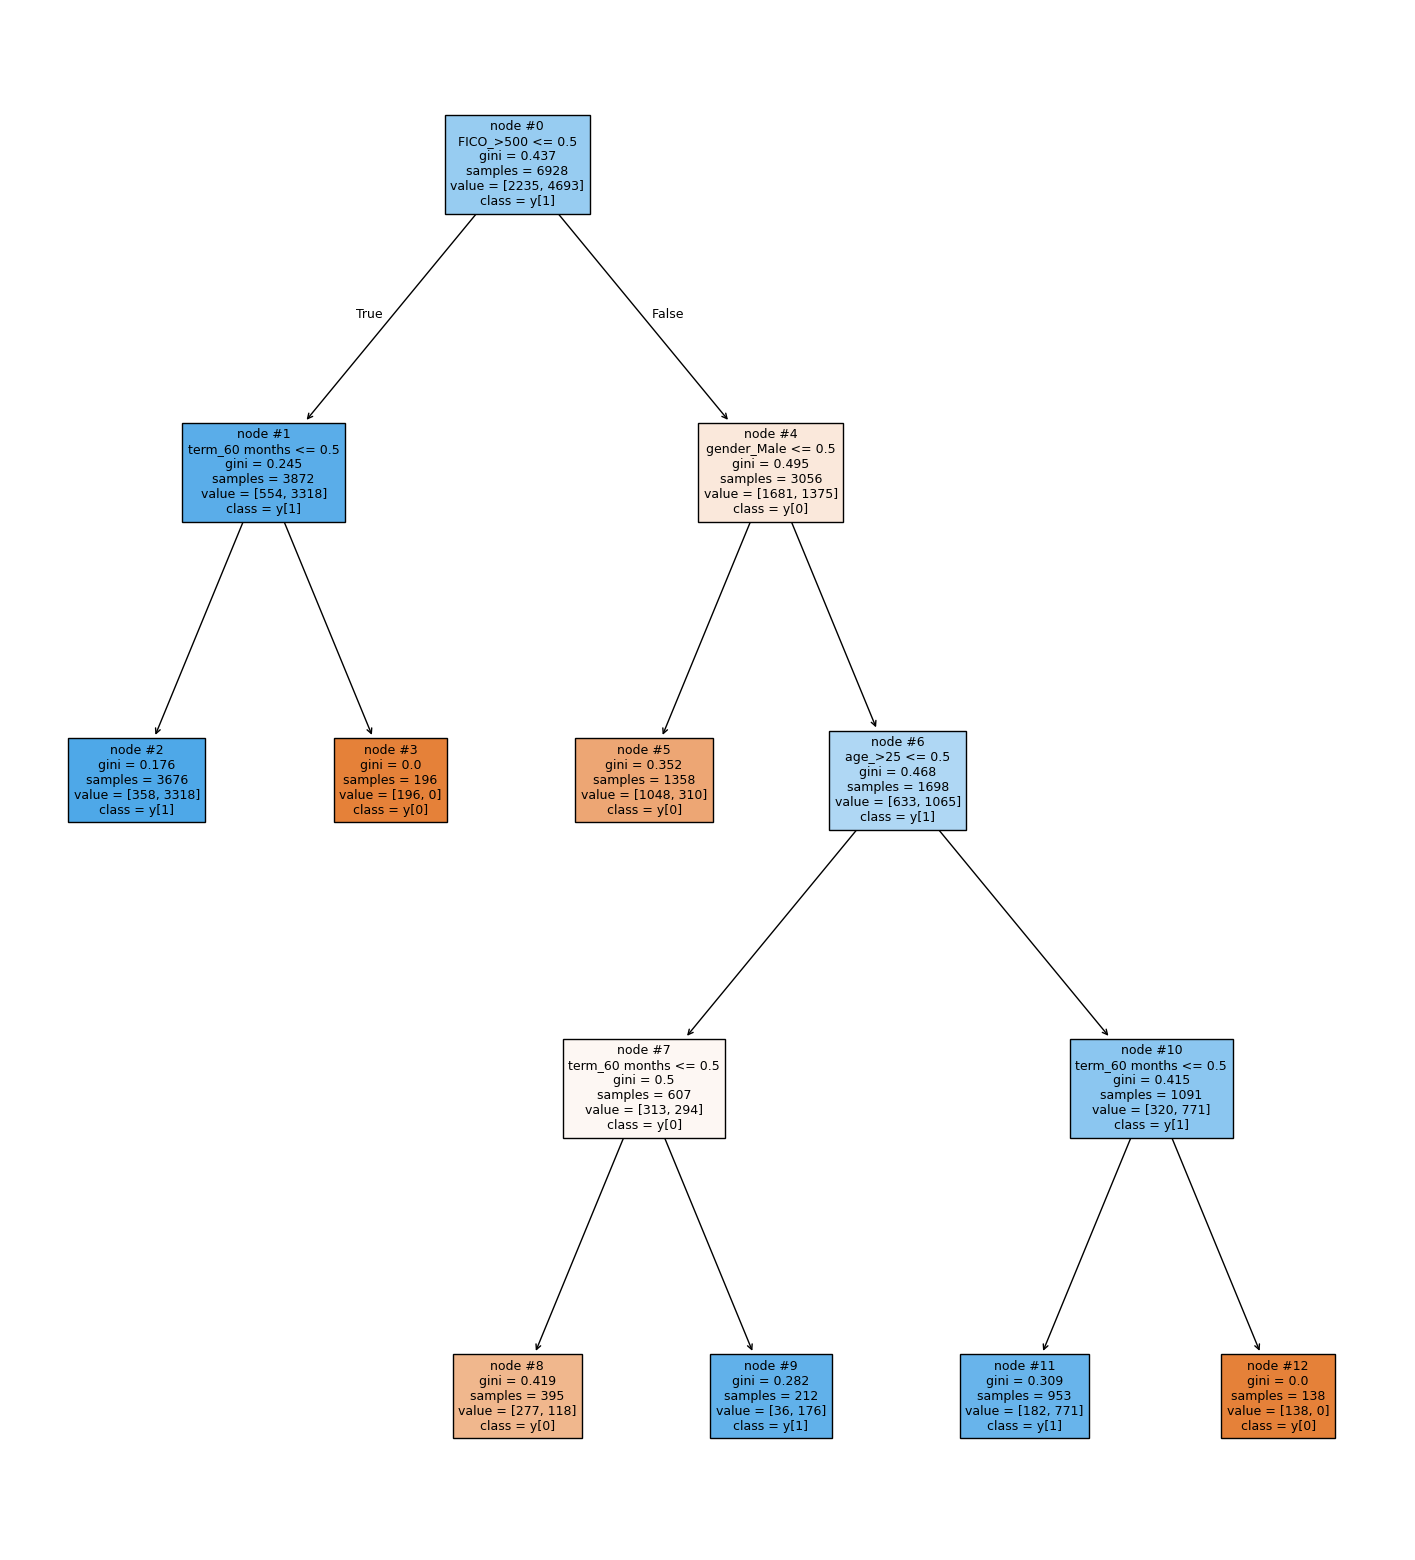

In [379]:
featurs_name = X.columns.tolist()

plt.figure(figsize=(18, 20))

plot = tree.plot_tree(
    dtree3,
    feature_names = featurs_name,
    filled = True,
    node_ids = True,
    fontsize = 9,
    class_names = True
)

In [380]:
feature_name = X.columns.tolist()
text_tree = tree.export_text(dtree3, feature_names= feature_name, show_weights= True)
print(text_tree)

|--- FICO_>500 <= 0.50
|   |--- term_60 months <= 0.50
|   |   |--- weights: [358.00, 3318.00] class: 1
|   |--- term_60 months >  0.50
|   |   |--- weights: [196.00, 0.00] class: 0
|--- FICO_>500 >  0.50
|   |--- gender_Male <= 0.50
|   |   |--- weights: [1048.00, 310.00] class: 0
|   |--- gender_Male >  0.50
|   |   |--- age_>25 <= 0.50
|   |   |   |--- term_60 months <= 0.50
|   |   |   |   |--- weights: [277.00, 118.00] class: 0
|   |   |   |--- term_60 months >  0.50
|   |   |   |   |--- weights: [36.00, 176.00] class: 1
|   |   |--- age_>25 >  0.50
|   |   |   |--- term_60 months <= 0.50
|   |   |   |   |--- weights: [182.00, 771.00] class: 1
|   |   |   |--- term_60 months >  0.50
|   |   |   |   |--- weights: [138.00, 0.00] class: 0



### **Feature Importance after Post-Pruned**

In [381]:
feature_importance_post_pruned = pd.DataFrame({
    "Features" : X.columns,
    "Importance" : dtree3.feature_importances_.round(4)
}).sort_values(by = ['Importance'], ascending = False).reset_index(drop=True)

print(feature_importance_post_pruned)

               Features  Importance
0             FICO_>500     0.40900
1        term_60 months     0.38950
2           gender_Male     0.17360
3               age_>25     0.02790
4         purpose_House     0.00000
5       purpose_Medical     0.00000
6         purpose_Other     0.00000
7       purpose_Wedding     0.00000
8      purpose_Personal     0.00000
9   home_ownership_Rent     0.00000
10   home_ownership_Own     0.00000


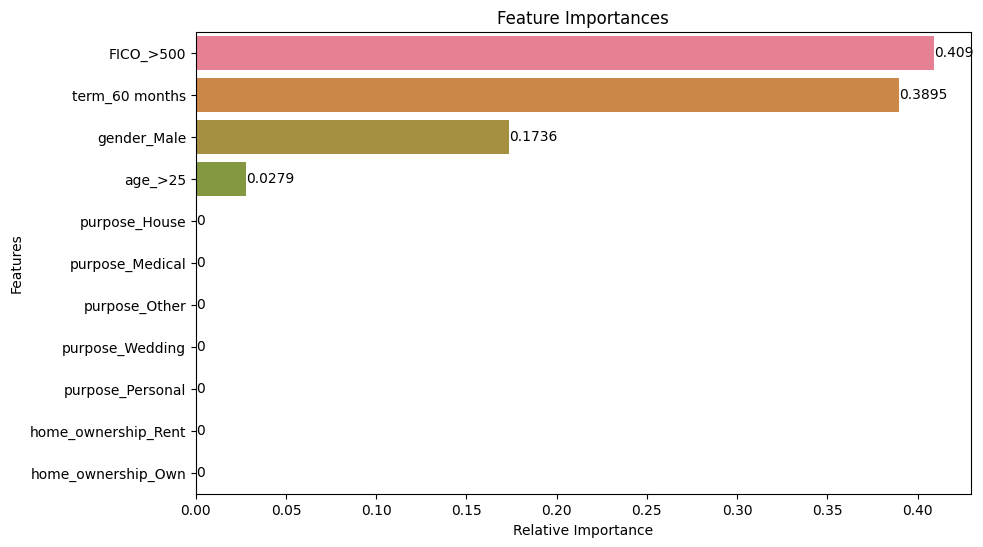

In [382]:
# plotting this above importance values in graph
plt.figure(figsize = (10,6))
plt.title("Feature Importances")
plot_3 = sns.barplot(feature_importance_post_pruned, x = 'Importance', y = 'Features', hue = 'Features')
plt.xlabel("Relative Importance")
plt.ylabel("Features")

for value in plot_3.containers:
  plot_3.bar_label(value)

plt.show()

## **Model Performance Comparison and Final Model Selection**

In [383]:
models_train_comparision  = pd.concat(
    [
        default_param_model_evaluation_train_data.T,
        pre_prun_model_evaluation_train_data.T,
        post_prun_model_evaluation_train_data.T
    ] , axis=1
)

models_train_comparision.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]

print("Training performance comparison:")
models_train_comparision

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.85551,0.85450,0.85508
Precision,0.88156,0.88155,0.88102
Recall,0.90880,0.90710,0.90880
F1-Score,0.89497,0.89414,0.89469
Error Rate,0.14449,0.14550,0.14492


In [384]:
models_test_comparision  = pd.concat(
    [
        default_param_model_evaluation_test_data.T,
        pre_prun_model_evaluation_test_data.T,
        post_prun_model_evaluation_test_data.T
    ] , axis=1
)

models_test_comparision.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]

print("Test performance comparison:")
models_test_comparision

Test performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.84372,0.84502,0.84481
Precision,0.86861,0.87028,0.86976
Recall,0.89729,0.89729,0.89762
F1-Score,0.88272,0.88358,0.88347
Error Rate,0.15628,0.15498,0.15519


Decision Tree with Post Pruning is giving the good Recall on test dataset.


### **Conclusions and Recommendations :**

* FICO, term and gender (in that order) are the most important variables in determining if a borrower will get into a delinquent stage
* No borrower shall be given a loan if they are applying for a 36 month term loan and
have a FICO score in the range 300-500.

* Female borrowers with a FICO score greater than 500 should be our target customers.
* Criteria to approve loan according to decision tree model should depend on three main factors - FICO score, duration of loan and gender that is - If the FICO score is less than 500 and the duration of loan is less than 60 months then the customer will not be able to repay the loans. If the customer has greater than 500 FICO score and is a female higher chances that they will repay the loans.